# EarlyStopping 학습

# 자동차 연비 회귀모델
- Auto MPG 데이터셋을 사용하여 1970년대 후반과 1980년대 초반의 자동차 연비를 예측하는 모델을 만듭니다. 
- 이 정보에는 실린더 수, 배기량, 마력(horsepower), 공차 중량 같은 속성이 포함됩니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

파일은 auto-mpg.csv 입니다.

In [3]:
df = pd.read_csv('./datas_dnn/auto-mpg.csv')

In [4]:
df.head()

,mpg,cyl,displ,hp,weight,accel,yr,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
df.isna().sum()

mpg       0
cyl       0
displ     0
hp        0
weight    0
accel     0
yr        0
origin    0
name      0
dtype: int64

In [6]:
y = df['mpg']

In [7]:
X = df.loc[ : ,'cyl' : 'origin' ]

In [8]:
X.head(2)

,cyl,displ,hp,weight,accel,yr,origin
0,8,307.0,130,3504,12.0,70,1
1,8,350.0,165,3693,11.5,70,1


In [9]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

# 데이터 준비

## 데이터 정규화

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

### X 데이터 정규화

In [11]:
# X데이터 정규화 객체
sc_X = MinMaxScaler()

In [12]:
X_scaled = sc_X.fit_transform(X)
X_scaled[:5]

array([[1.        , 0.61757106, 0.45652174, 0.5361497 , 0.23809524,
        0.        , 0.        ],
       [1.        , 0.72868217, 0.64673913, 0.58973632, 0.20833333,
        0.        , 0.        ],
       [1.        , 0.64599483, 0.56521739, 0.51686986, 0.17857143,
        0.        , 0.        ],
       [1.        , 0.60981912, 0.56521739, 0.51601928, 0.23809524,
        0.        , 0.        ],
       [1.        , 0.60465116, 0.51086957, 0.52055571, 0.14880952,
        0.        , 0.        ]])

### y 데이터 2차원 reshaphe, 정규화
- 딥러닝에서 데이터 학습이 더 잘됨

In [13]:
# y데이터 정규화 객체
sc_y = MinMaxScaler()

In [14]:
y.shape

(392,)

In [15]:
y.values.reshape(-1,1)[:5]

array([[18.],
       [15.],
       [18.],
       [16.],
       [17.]])

In [16]:
y_scaled = sc_y.fit_transform(y.values.reshape(-1,1))

In [17]:
y_scaled[:5]

array([[0.2393617 ],
       [0.15957447],
       [0.2393617 ],
       [0.18617021],
       [0.21276596]])

### 학습, 테스트 데이터 분할

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, 
    test_size=0.2, 
    random_state=42)

# 딥러닝 모델링

- 텐서플로 2.19 버전에서 바뀐 내용: 옵티마이저 방법을 문자열 형식 대신 객체형식으로 하면 직렬화를 더 작한다고 함.

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.optimizers import Adam

I0000 00:00:1788105870.365792   43163 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788105870.925417   43163 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788105881.965083   43163 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# build_model() 함수 정의
# input_dim을 입력 받음
# hidden layer 2개, 각 레이어의 노드 수는 54개, 활성화 함수 'relu'
# 출력층 : 활성화 함수 linear 
# 모델 최적화 : Adam(learning_rate=0.001), loss='mse',  metrics=['mae']
# 컴파일한 모델 리턴
def build_model( input_dim ) :
  





  
  return model



In [ ]:
# 모델 생성 함수 호출
model = build_model( X_train.shape[1] )

I0000 00:00:1788105960.109188   43163 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1402 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1


In [ ]:
# 모델 요약하기


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train.shape

(313, 7)

# 학습 히스토리 확인

In [ ]:
# 모델 학습하기
# 500번 학습, 
# 학습하면서 validation 체크하기 비율은 0.2
# 학습 log 출력하지 않기
history = 

In [ ]:
# 화면으로 출력한 결과가 기록 되어 있음
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

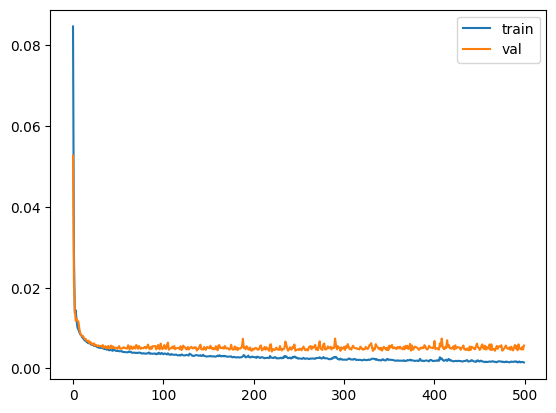

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()

이 그래프를 보면 수 백번 에포크를 진행한 이후에는 모델이 거의 향상되지 않는 것 같습니다. model.fit 메서드를 수정하여 검증 점수가 향상되지 않으면 자동으로 훈련을 멈추도록 만들어 보죠. 에포크마다 훈련 상태를 점검하기 위해 EarlyStopping 콜백(callback)을 사용하겠습니다. 지정된 에포크 횟수 동안 성능 향상이 없으면 자동으로 훈련이 멈춥니다.

이 콜백에 대해 더 자세한 내용은 여기를 참고하세요.[링크 텍스트](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)

# 학습 자동 중단